# Amazon Electronics Intelligence

A Data Science project analyzing product reviews from the Amazon Electronics category.

**Dataset:** Amazon Electronics 5-core (reviews_Electronics_5.json)  
**Source:** [Julian McAuley, UCSD](http://jmcauley.ucsd.edu/data/amazon/)

In [2]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

---
## 1. Data Loading & Initial Overview

The dataset contains product reviews from the Amazon Electronics category. Each row is a JSON object (line-delimited JSON format).

In [3]:
# Load the dataset
df = pd.read_json('../../reviews_Electronics_5.json/Electronics_5.json', lines=True)
print(f'Dataset loaded successfully!')
print(f'Number of rows: {df.shape[0]:,}')
print(f'Number of columns: {df.shape[1]}')

Dataset loaded successfully!
Number of rows: 1,689,188
Number of columns: 9


In [ ]:
# First 5 rows
df.head()

In [ ]:
# Column types and null info
df.info()

In [ ]:
# Summary statistics for numerical columns
df.describe()

### Column Descriptions

| Column | Description |
|--------|-------------|
| `reviewerID` | Unique identifier of the reviewer |
| `asin` | Amazon Standard Identification Number (unique product ID) |
| `reviewerName` | Display name of the reviewer |
| `helpful` | Helpfulness votes - [number of helpful votes, total votes] |
| `reviewText` | Full text of the review |
| `overall` | Product rating (1.0 - 5.0) |
| `summary` | Short title/summary of the review |
| `unixReviewTime` | Timestamp of the review (Unix epoch) |
| `reviewTime` | Date of the review (human-readable format) |

In [3]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Rate (%)': missing_pct
})

print('Missing Value Summary:')
print('=' * 40)
missing_df

Missing Value Summary:


,Missing Count,Missing Rate (%)
reviewerID,0,0.00
asin,0,0.00
reviewerName,24730,1.46
helpful,0,0.00
reviewText,0,0.00
overall,0,0.00
summary,0,0.00
unixReviewTime,0,0.00
reviewTime,0,0.00


In [ ]:
# Unique value counts
print('Unique Values per Column:')
print('=' * 40)
for col in df.columns:
    print(f'{col:20s} -> {df[col].nunique():>10,} unique values')

---
## 2. Descriptive Statistics

Getting the big picture of the dataset through rating distribution, most reviewed products, and most active reviewers.

### 2.1 Rating Distribution

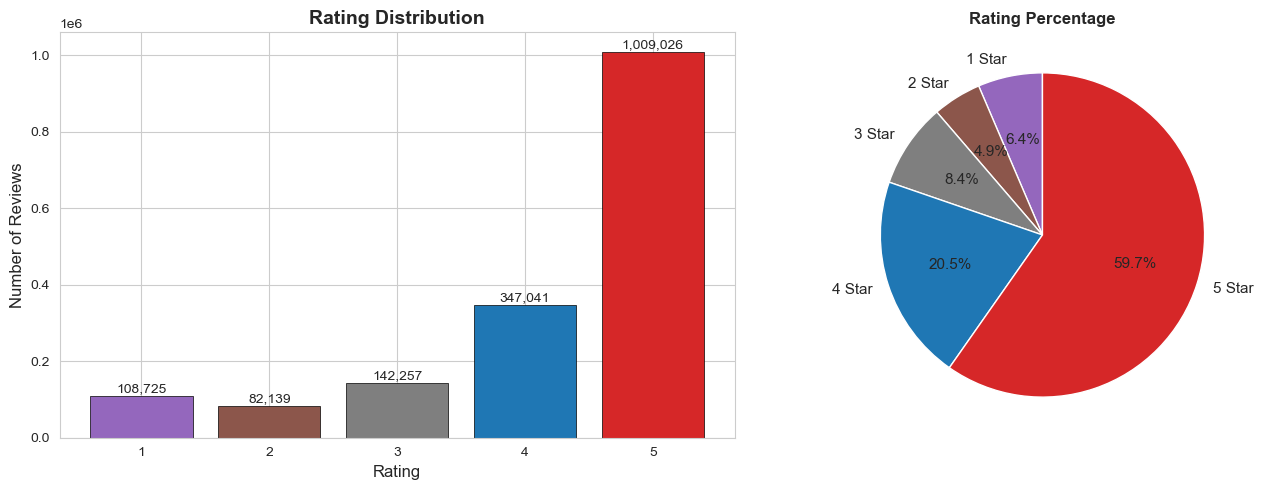

Average Rating: 4.22
Median Rating: 5.0
Mode Rating: 5.0


In [13]:
# Rating distribution
rating_counts = df['overall'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Bar chart
colors = ['#9467bd', '#8c564b', '#7f7f7f', '#1f77b4', '#d62728']
ax[0].bar(rating_counts.index, rating_counts.values, color=colors , edgecolor='black', linewidth=0.5)
ax[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Number of Reviews', fontsize=12)
ax[0].set_xticks([1, 2, 3, 4, 5])

# Percentage pie chart
for i, v in enumerate(rating_counts.values):
    offset = rating_counts.max() * 0.01
    ax[0].text(rating_counts.index[i], v + offset, f'{v:,}', ha='center', fontsize=10)
    
ax[1].pie(rating_counts.values, labels=[f'{int(r)} Star' for r in rating_counts.index], autopct='%1.1f%%',
       colors=colors, startangle=90, textprops={'fontsize': 11})
ax[1].set_title('Rating Percentage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


print(f'Average Rating: {df["overall"].mean():.2f}')
print(f'Median Rating: {df["overall"].median():.1f}')
print(f'Mode Rating: {df["overall"].mode()[0]:.1f}')

### 2.2 Most Reviewed Products (Top 10)

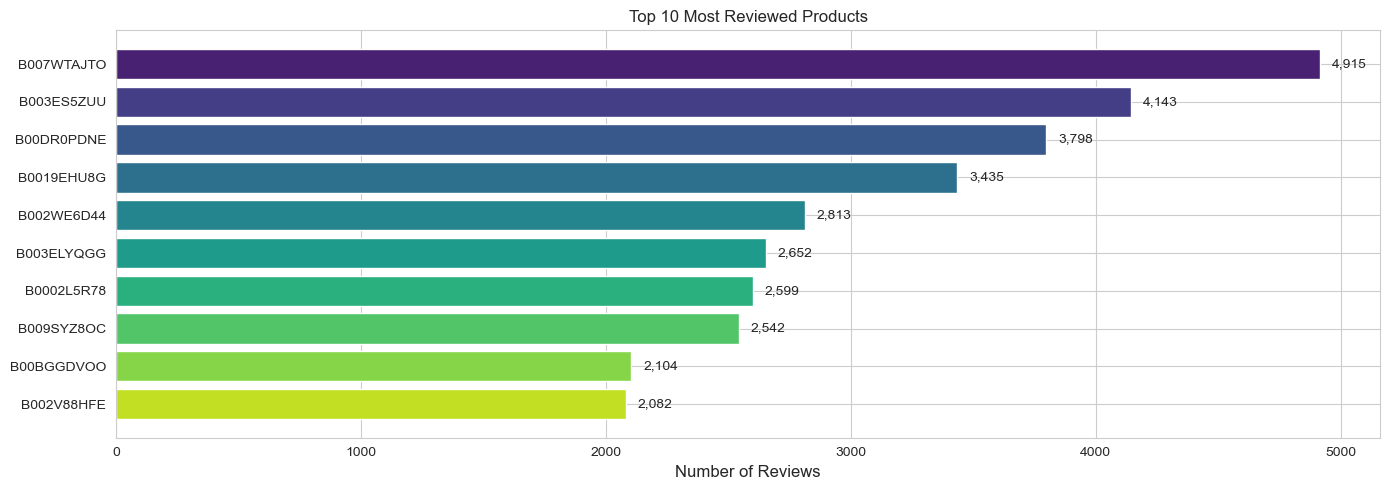

Total unique products: 63,001
Average reviews per product: 26.8


In [ ]:
# Top 10 most reviewed products
top_products = df['asin'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14,5))

ax.barh(range(len(top_products)), top_products.values, color=sns.color_palette('viridis',10))
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels(top_products.index, fontsize=10)
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title('Top 10 Most Reviewed Products' ,fontsize=14, fontweight='bold')
ax.invert_yaxis()

offset=top_products.max()*0.01
for i,v in enumerate(top_products.values):
    ax.text(v + offset, i, f'{v:,}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

print(f'Total unique products: {df["asin"].nunique():,}')
print(f'Average reviews per product: {df.groupby("asin").size().mean():.1f}')


### 2.3 Most Active Reviewers (Top 10)

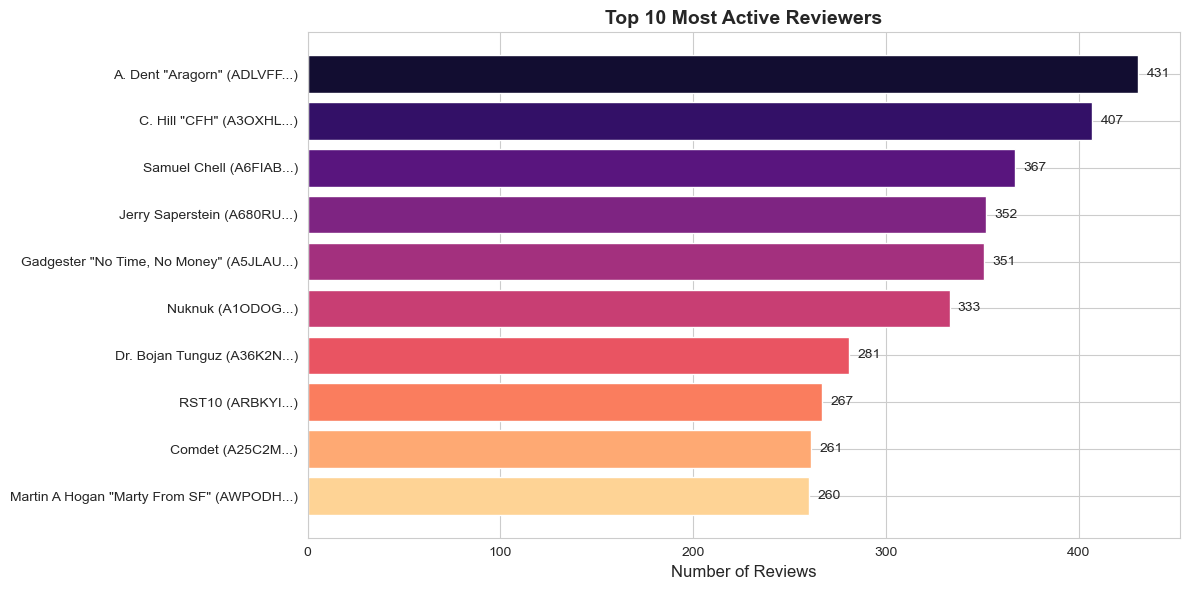

Total unique reviewers: 192,403
Average reviews per user: 8.8


In [14]:
# Top 10 most active reviewers
top_reviewers = df['reviewerID'].value_counts().head(10)

# Get reviewer names where available
reviewer_names = df.drop_duplicates('reviewerID').set_index('reviewerID')['reviewerName']
labels = [f'{reviewer_names.get(rid, "Unknown")} ({rid[:6]}...)' for rid in top_reviewers.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_reviewers)), top_reviewers.values, color=sns.color_palette('magma', 10))
ax.set_yticks(range(len(top_reviewers)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title('Top 10 Most Active Reviewers', fontsize=14, fontweight='bold')
ax.invert_yaxis()

offset=top_reviewers.max()*0.01
for i, v in enumerate(top_reviewers.values):
    ax.text(v + offset, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Total unique reviewers: {df["reviewerID"].nunique():,}')
print(f'Average reviews per user: {df.groupby("reviewerID").size().mean():.1f}')